# Day 8: Application: IR Spectra

## Excercises
1. Calculate the IR spectra for all compounds mentioned in the training notes.
2. Calculate the hydrogenation energy for the reactions where you have experimental data for comparison.


In [2]:
from ase.build import molecule
from ase.optimize import BFGS
from ase.vibrations import Infrared
from pymolpro import ASEMolpro
from ase.io import read, write
import pymolpro
import numpy as np
import matplotlib.pyplot as plt
from ase.data.pubchem import pubchem_atoms_search
from ase.visualize import view
from ase.units import kJ,mol

Build and optimize the structures of the compounds you need. Use either the molecule function in ASE or pubchem_atoms_search to get the initial structures. Optimize the structures using PBE and def2-SVP. Save the optimized structures for later use as xyz files. The optimization of salicylic acid takes quite long, so the optimized structure is provided on Ilias.

In [18]:
allyl_alcohol = pubchem_atoms_search("Allylalcohol")
acrylic_acid = pubchem_atoms_search("79-10-7")
dichloromethane = pubchem_atoms_search("Dichloromethane")
cyclohexan = pubchem_atoms_search("Cyclohexan")
salicylic_acid = read("salicylic_acid.xyz")
H2 = molecule("H2")
H2O = molecule("H2O")
CO2 = molecule("CO2")
C6H6 = molecule("C6H6")
cyclohexen = pubchem_atoms_search("Cyclohexen")
propanol = pubchem_atoms_search("Propanol")
propionic_acid = pubchem_atoms_search("79-09-4")

for atom in [allyl_alcohol, acrylic_acid, dichloromethane, cyclohexan, H2, H2O, CO2, C6H6, cyclohexen, propanol, propionic_acid]:
    atom.calc = ASEMolpro(ansatz="PBE/def2-SVP", density_fitting=True)
    with BFGS(atom, trajectory=f'{atom.get_chemical_formula()}.traj') as opt:
        opt.run(fmax=0.05)

/home/CompChem3/miniconda3/envs/compchem/lib/python3.11/site-packages/ase/data/pubchem.py:74: UserWarning: The structure "Allylalcohol" has more than one conformer in PubChem. By default, the first conformer is returned, please ensure you are using the structure you intend to or use the `ase.data.pubchem.pubchem_conformer_search` function
  warnings.warn(
/home/CompChem3/miniconda3/envs/compchem/lib/python3.11/site-packages/ase/data/pubchem.py:74: UserWarning: The structure "Propanol" has more than one conformer in PubChem. By default, the first conformer is returned, please ensure you are using the structure you intend to or use the `ase.data.pubchem.pubchem_conformer_search` function
  warnings.warn(
/home/CompChem3/miniconda3/envs/compchem/lib/python3.11/site-packages/ase/data/pubchem.py:74: UserWarning: The structure "79-09-4" has more than one conformer in PubChem. By default, the first conformer is returned, please ensure you are using the structure you intend to or use the `ase.

      Step     Time          Energy          fmax
BFGS:    0 14:24:06    -5244.283105        1.137400
BFGS:    1 14:24:16    -5244.324082        0.753022
BFGS:    2 14:24:26    -5244.343908        0.480735
BFGS:    3 14:24:36    -5244.352877        0.246670
BFGS:    4 14:24:45    -5244.356164        0.182808
BFGS:    5 14:24:55    -5244.361733        0.216145
BFGS:    6 14:25:06    -5244.365137        0.165876
BFGS:    7 14:25:16    -5244.366786        0.094358
BFGS:    8 14:25:27    -5244.367409        0.079864
BFGS:    9 14:25:37    -5244.367999        0.081441
BFGS:   10 14:25:48    -5244.368447        0.072029
BFGS:   11 14:25:59    -5244.368711        0.056043
BFGS:   12 14:26:09    -5244.368737        0.046208
      Step     Time          Energy          fmax
BFGS:    0 14:26:20    -7256.280146        1.140251
BFGS:    1 14:26:31    -7256.306196        1.121476
BFGS:    2 14:26:41    -7256.326504        0.348657
BFGS:    3 14:26:52    -7256.333293        0.301923
BFGS:    4 14:27

In [19]:
write("Allyl_Alcohol.xyz", allyl_alcohol)
write("Acrylic_Acid.xyz", acrylic_acid)
write("Dichloromethane.xyz", dichloromethane)
write("Cyclohexan.xyz", cyclohexan)
write("H2.xyz", H2)
write("H2O.xyz", H2O)
write("CO2.xyz", CO2)
write("C6H6.xyz", C6H6)
write("Cyclohexen.xyz", cyclohexen)
write("Propanol.xyz", propanol)
write("Propionic_Acid.xyz", propionic_acid)

## Simulating the IR spectra

Now, we want to simulate the IR spectra for the compounds. For this, we need to calculate the vibrational frequencies and the corresponding intensities. To do this, we need to create a new project for each compound and set up the calculation for the vibrational frequencies using Molpro input. We will use the xyz files of the optimized structures from the previous step as input for these calculations. The input includes:
- the absolute path to the xyz file
- the basis set
- the method as {ks, pbe}
- the keyword for the frequency calculation {freq}

Start with one compound first to make sure that the workflow is correct.

Do NOT calculate the spectrum of salicylic acid, as it takes quite long. The output file for the frequency calculation of salicylic acid is provided on Ilias.

In [27]:
# define project name for the next molecule
project_name = "Allyl_Alcohol"

In [30]:
project = pymolpro.Project(project_name)

molpro_input = """

geometry=/home/CompChem3/Documents/Compchem/8/Allyl_Alcohol.xyz

basis=def2-SVP

{ks, pbe}

{freq}

"""
project.write_input(molpro_input)
project.run()
project.run(wait=True)

To evaluate the calculations, we need to extract the vibrational frequencies and the corresponding intensities from the output files. So first, we create the filename of the output file based on the project name and the run number. 

In [31]:
run = 1
project_file = project_name + ".molpro/run/" + project_name + "_" + str(run) + ".molpro/" + project_name + "_" + str(run) + ".out"
print(project_file)

Allyl_Alcohol.molpro/run/Allyl_Alcohol_1.molpro/Allyl_Alcohol_1.out


To extract the intensities and frequencies, we can use the following function:

In [32]:
def extract_peaks_from_molpro_output(file_path):

    wavenumbers = []
    intensities = []

    with open(file_path, 'r') as file:
        for line in file:
            # Clean up any leading/trailing whitespace
            clean_line = line.strip()
            
            # Search if "Wavenumbers" is in the line
            if clean_line.startswith('Wavenumbers [cm-1]'):
                # split() breaks the line into a list of words based on spaces
                # We slice [2:] to skip the words "Wavenumbers" and "[cm-1]"
                numbers = clean_line.split()[2:]
                wavenumbers.extend([float(num) for num in numbers])
                
            # Search if "Intensities" is in the line
            elif clean_line.startswith('Intensities [relative]'):
                numbers = clean_line.split()[2:]
                intensities.extend([float(num) for num in numbers])

    # Zip them together into the (x, y) pairs 
    # We will also filter out the peaks with 0.00 intensity to save calculation time
    peaks = [(w, i) for w, i in zip(wavenumbers, intensities) if i > 0.0]

    return peaks

Now use the function to extract the peaks from the output files of your calculations and take a look at them. Each entry in the list should be a tuple containing the wavenumber and the corresponding intensity.

In [33]:
peaks = extract_peaks_from_molpro_output(project_file)

Lastly, we want to plot the spectrum. We can use the following code to do that:

In [41]:
def plot_ir_spectrum(peaks, title):    
    # Unpack the data into x and y lists
    x = [peak[0] for peak in peaks]
    y = [peak[1] for peak in peaks]

    # 2. Set up the figure
    plt.figure(figsize=(10, 6))

    # Draw the straight downward lines
    # x = wavenumbers
    # ymin = 0 (the top line where the stick starts)
    # ymax = y (the intensity where the stick ends)
    plt.vlines(x, ymin=0, ymax=y, color='black', linewidth=2)

    # Invert the axes to match IR conventions
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()

    plt.xlim(4000, 500)

    plt.xlabel("Wavenumber [$(c m)^(-1)$]")
    plt.ylabel("Relative Transmittance")
    plt.title(title)

    # Add the inside tick marks all the way around the box
    plt.minorticks_on()
    plt.tick_params(which='both', direction='in', top=True, right=True, length=6)

    # Show the plot
    plt.tight_layout()
    plt.show()

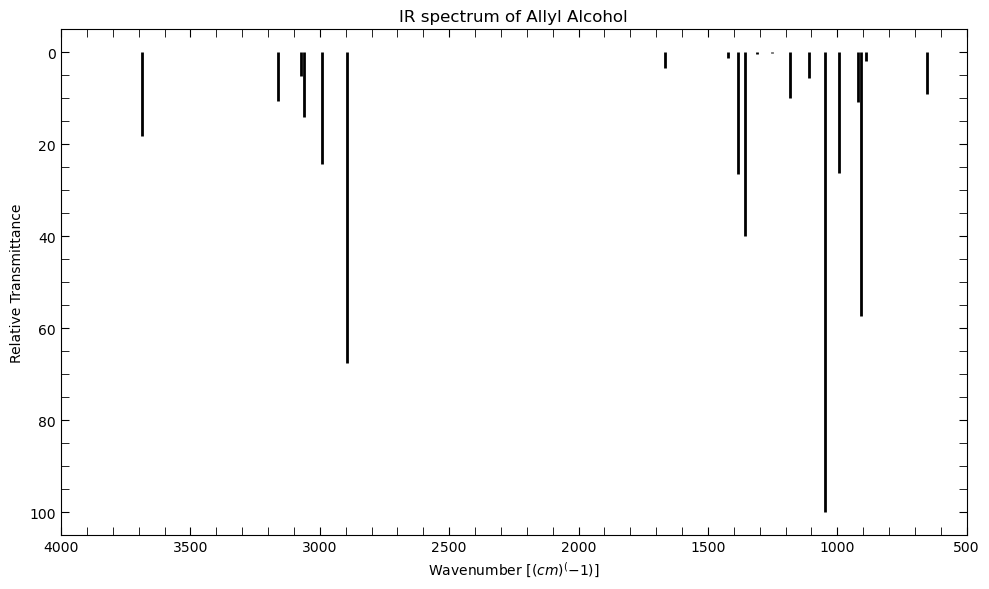

In [42]:
plot_ir_spectrum(peaks, "IR spectrum of Allyl Alcohol")

Now, continue with the other compounds and plot their spectra as well. 

In [45]:
def generate_spectra(project_name: str):
    project = pymolpro.Project(project_name)

    molpro_input = f"""

    geometry=/home/CompChem3/Documents/Compchem/8/{project_name}.xyz

    basis=def2-SVP

    {"{ks, pbe}"}

    {"{freq}"}

    """
    project.write_input(molpro_input)
    project.run()
    project.run(wait=True)

    project_file = project_name + ".molpro/run/" + project_name + "_1.molpro/" + project_name + "_" + str(run) + ".out"

    peaks = extract_peaks_from_molpro_output(project_file)

    plot_ir_spectrum(peaks, "IR spectrum of {}".format(project_name.replace("_", " ")))

In [ ]:
generate_spectra("Cyclohexen")

## Hydrogenation Energies
Calculate the hydrogenation energies in kJ/mol for the reactions where you have the experimental data for comparison. 

In [53]:
# Cyclohexen
print(f"Hydrogenation energy for Cyclohexen: {(cyclohexan.get_potential_energy() - H2.get_potential_energy() - cyclohexen.get_potential_energy()) * mol/kJ :.3f} [kJ/mol]")

# Salicylic Acid
salicylic_acid.calc = ASEMolpro(ansatz="PBE/def2-SVP", density_fitting=True)
print(f"Hydrogenation energy for Salicylic Acid: {(C6H6.get_potential_energy() + CO2.get_potential_energy() + H2O.get_potential_energy() - H2.get_potential_energy() - salicylic_acid.get_potential_energy()) * mol/kJ:.3f} [kJ/mol]")

Hydrogenation energy for Cyclohexen: -155.353 [kJ/mol]
Hydrogenation energy for Salicylic Acid: -59.359 [kJ/mol]
